In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("State_Power_Position_All_Days.csv",on_bad_lines="skip")

In [4]:

df.head()

,C.Power Supply Position in States,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Date
0,RegionRegion,States,Max. Demand Met\nduring the day\n(MW),Peak hour\nShortage (MW),Energy\nMet (MU),Drawal\nSchedule (MU),OD(+)/\nUD(-) (MU),Max\nOD (MW),01.01.14
1,NR,Punjab,4792,0,89.5,36.6,1.4,307,01.01.14
2,NaN,Haryana,5354,0,98.2,35.7,1.0,455,01.01.14
3,NaN,Rajasthan,8942,0,183.3,73.6,-1.0,478,01.01.14
4,NaN,Delhi,3711,0,65.2,44.6,0.6,311,01.01.14


In [5]:
df.shape

(58775, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58775 entries, 0 to 58774
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   C.Power Supply Position in States  10297 non-null  object
 1   Unnamed: 1                         58623 non-null  object
 2   Unnamed: 2                         58069 non-null  object
 3   Unnamed: 3                         58643 non-null  object
 4   Unnamed: 4                         58511 non-null  object
 5   Unnamed: 5                         58497 non-null  object
 6   Unnamed: 6                         58555 non-null  object
 7   Unnamed: 7                         58048 non-null  object
 8   Date                               57859 non-null  object
dtypes: object(9)
memory usage: 4.0+ MB


In [7]:
df.columns = [
    "Region",
    "State",
    "Peak_Demand",
    "Peak_Met",
    "Energy_Requirement",
    "Energy_Supplied",
    "Shortage",
    "Max_Outage",
    "Date"
]

In [8]:
print(df.columns)

Index(['Region', 'State', 'Peak_Demand', 'Peak_Met', 'Energy_Requirement',
       'Energy_Supplied', 'Shortage', 'Max_Outage', 'Date'],
      dtype='object')


In [9]:
df.isnull().sum()

Region                48478
State                   152
Peak_Demand             706
Peak_Met                132
Energy_Requirement      264
Energy_Supplied         278
Shortage                220
Max_Outage              727
Date                    916
dtype: int64

In [10]:
df["Region"] = df["Region"].fillna(method="ffill")

In [11]:
df["Peak_Demand"].fillna(df["Peak_Demand"].mean(), inplace=True)

TypeError: can only concatenate str (not "int") to str

In [12]:
df["Peak_Demand"].dtype

dtype('O')

In [13]:
df["Peak_Demand"] = pd.to_numeric(df["Peak_Demand"], errors="coerce")

In [14]:
df["Peak_Demand"].dtype

dtype('float64')

In [15]:
df["Peak_Demand"].fillna(df["Peak_Demand"].mean(), inplace=True)

In [16]:
numeric_columns = [
    "Peak_Demand",
    "Peak_Met",
    "Energy_Requirement",
    "Energy_Supplied",
    "Shortage",
    "Max_Outage"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [17]:
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58775 entries, 0 to 58774
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Region              58775 non-null  object 
 1   State               58623 non-null  object 
 2   Peak_Demand         58775 non-null  float64
 3   Peak_Met            58775 non-null  float64
 4   Energy_Requirement  58775 non-null  float64
 5   Energy_Supplied     58775 non-null  float64
 6   Shortage            58775 non-null  float64
 7   Max_Outage          58775 non-null  float64
 8   Date                57859 non-null  object 
dtypes: float64(6), object(3)
memory usage: 4.0+ MB


In [19]:
df["Region"] = df["Region"].fillna(method="ffill")

In [20]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [21]:
df["Date"].head()

0   2014-01-01
1   2014-01-01
2   2014-01-01
3   2014-01-01
4   2014-01-01
Name: Date, dtype: datetime64[ns]

In [29]:
df["Year"] = df["Date"].dt.year

In [30]:
df["Month"] = df["Date"].dt.month

In [31]:
df.head()

,Region,State,Peak_Demand,Peak_Met,Energy_Requirement,Energy_Supplied,Shortage,Max_Outage,Date,Year,Month
0,RegionRegion,States,3906.464602,128.760581,87.995455,39.062142,0.539714,221.640315,2014-01-01,2014.0,1.0
1,NR,Punjab,4792.000000,0.000000,89.500000,36.600000,1.400000,307.000000,2014-01-01,2014.0,1.0
2,NR,Haryana,5354.000000,0.000000,98.200000,35.700000,1.000000,455.000000,2014-01-01,2014.0,1.0
3,NR,Rajasthan,8942.000000,0.000000,183.300000,73.600000,-1.000000,478.000000,2014-01-01,2014.0,1.0
4,NR,Delhi,3711.000000,0.000000,65.200000,44.600000,0.600000,311.000000,2014-01-01,2014.0,1.0


In [32]:
state_demand = df.groupby("State")["Peak_Demand"].mean()

print(state_demand)

State
-101                            -360.000000
-1026                          -1637.000000
-107                            -421.000000
-1076                          -1585.000000
-138                            -502.000000
                                   ...     
Wind Power                      3906.464602
Wind power                      3906.464602
ampa ( CChGh)a ttisgarh         3906.464602
kota TPS (2*110+2*195+3*210)    3906.464602
suratgarh TPS (6*250)           3906.464602
Name: Peak_Demand, Length: 322, dtype: float64


In [33]:
year_demand = df.groupby("Year")["Peak_Demand"].mean()

print(year_demand)

Year
2013.0    3631.838557
2014.0    3781.143040
2015.0    3895.737957
2016.0    4126.483691
2017.0    4346.205362
2020.0    3911.613618
Name: Peak_Demand, dtype: float64


In [27]:
Q1 = df["Peak_Demand"].quantile(0.25)
Q3 = df["Peak_Demand"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Peak_Demand"] < lower) | (df["Peak_Demand"] > upper)]

print(outliers)


      Region        State  Peak_Demand  Peak_Met  Energy_Requirement  \
13        WR  Maharashtra      17714.0      73.0               360.0   
49        WR  Maharashtra      17541.0      67.0               356.7   
86        WR  Maharashtra      18404.0      14.0               369.5   
123       WR  Maharashtra      19976.0       0.0               388.1   
160       WR  Maharashtra      18402.0     231.0               365.1   
...      ...          ...          ...       ...                 ...   
58533     WR  Maharashtra      17744.0       0.0               382.4   
58641     WR  Maharashtra      17188.0      92.0               360.7   
58677     WR  Maharashtra      17960.0     711.0               365.7   
58714     WR  Maharashtra      18531.0      11.0               368.3   
58751     WR  Maharashtra      19601.0       0.0               400.9   

       Energy_Supplied  Shortage  Max_Outage       Date    Year  Month  
13               105.5       5.5       526.0 2014-01-01  2014.

In [34]:
df = df[(df["Peak_Demand"] >= lower) & (df["Peak_Demand"] <= upper)]

NameError: name 'lower' is not defined

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Demand_Normalized"] = scaler.fit_transform(df[["Peak_Demand"]])

In [30]:
df[["Peak_Demand","Demand_Normalized"]].head()

,Peak_Demand,Demand_Normalized
0,3906.464602,0.327241
1,4792.000000,0.379516
2,5354.000000,0.412692
3,8942.000000,0.624498
4,3711.000000,0.315702


In [36]:
correlation_matrix = df.corr()

print(correlation_matrix)

                    Peak_Demand  Peak_Met  Energy_Requirement  \
Peak_Demand            1.000000  0.185385            0.342074   
Peak_Met               0.185385  1.000000            0.750193   
Energy_Requirement     0.342074  0.750193            1.000000   
Energy_Supplied        0.151084  0.785359            0.930136   
Shortage               0.034437  0.534492            0.749533   
Max_Outage             0.146105  0.306471            0.428586   
Year                   0.045178 -0.036446            0.047714   
Month                 -0.004892  0.001686           -0.004970   
Demand_Normalized      1.000000  0.185385            0.342074   

                    Energy_Supplied  Shortage  Max_Outage      Year     Month  \
Peak_Demand                0.151084  0.034437    0.146105  0.045178 -0.004892   
Peak_Met                   0.785359  0.534492    0.306471 -0.036446  0.001686   
Energy_Requirement         0.930136  0.749533    0.428586  0.047714 -0.004970   
Energy_Supplied          

C:\Users\rjesh\AppData\Local\Temp\ipykernel_14592\1598865583.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


In [37]:
features = df[[
    "Peak_Demand",
    "Peak_Met",
    "Energy_Requirement",
    "Energy_Supplied"
]]

In [38]:
features = features.dropna()

In [39]:
from sklearn.preprocessing import StandardScaler

scaled_features = StandardScaler().fit_transform(features)

[[-3.02912781e-15  1.61427426e-13]
 [-6.48486072e-02 -2.28162984e-01]
 [-2.15120098e-02 -3.50933191e-01]
 [ 4.28292483e-01 -1.09237194e+00]
 [-1.47253208e-01  1.42106790e-02]]


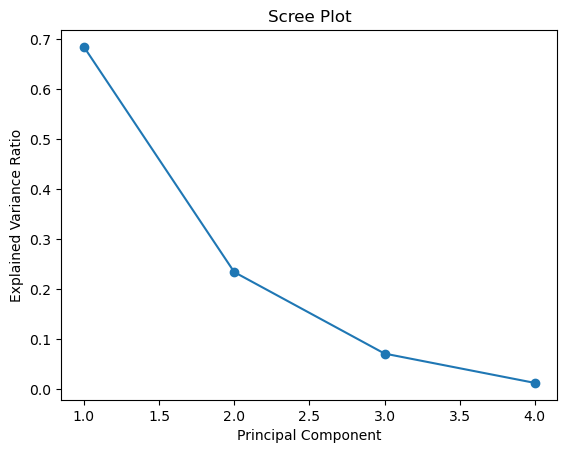

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_features)

print(principal_components[:5])

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA (keep all components first for scree plot)
pca = PCA()
pca.fit(scaled_features)

# Explained variance (eigenvalues)
explained_variance = pca.explained_variance_ratio_

# Scree Plot
plt.figure()
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

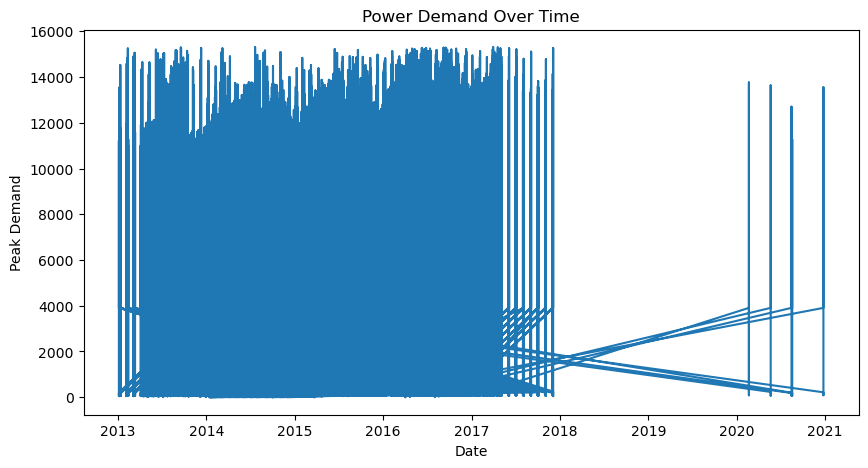

In [36]:
plt.figure(figsize=(10,5))

plt.plot(df["Date"], df["Peak_Demand"])

plt.xlabel("Date")
plt.ylabel("Peak Demand")

plt.title("Power Demand Over Time")

plt.show()

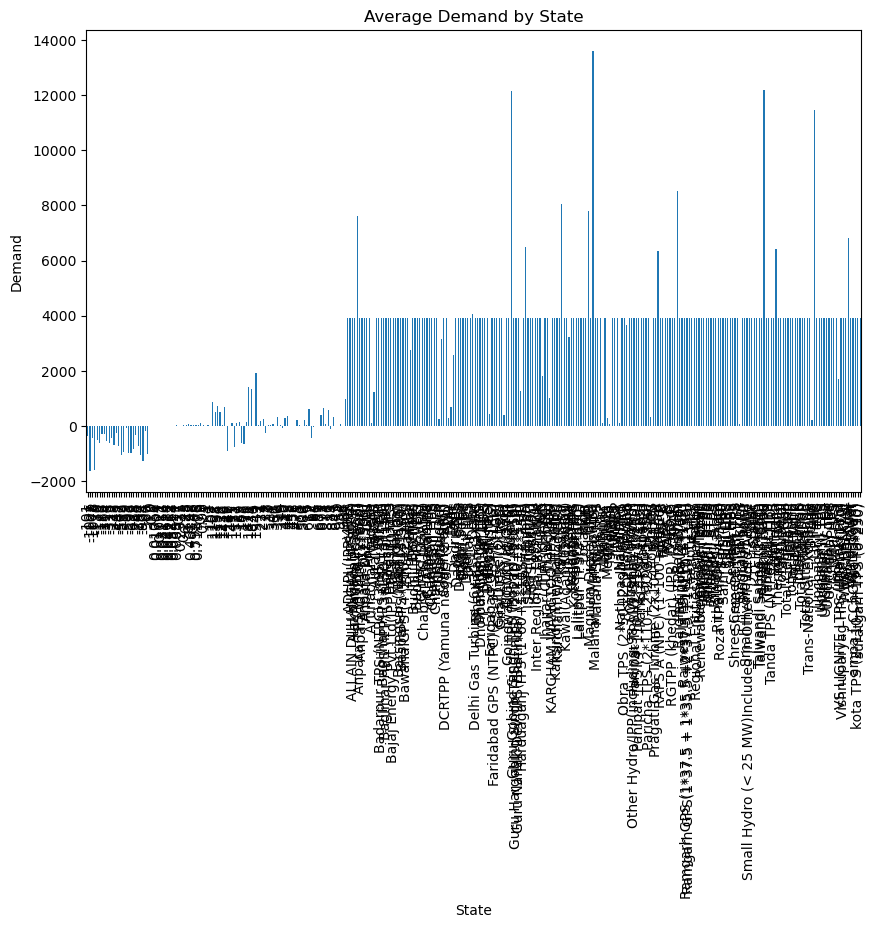

In [37]:
state_demand = df.groupby("State")["Peak_Demand"].mean()

state_demand.plot(kind="bar", figsize=(10,6))

plt.title("Average Demand by State")
plt.xlabel("State")
plt.ylabel("Demand")

plt.show()

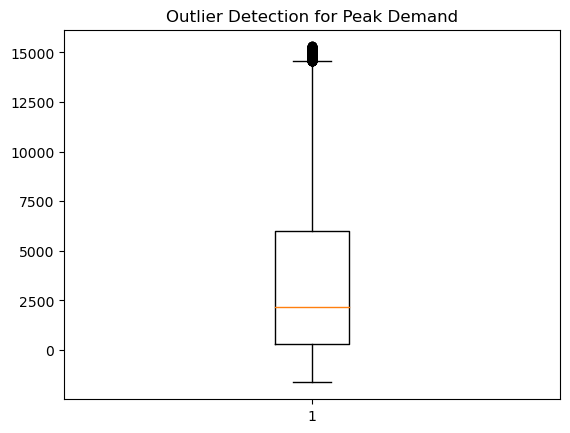

In [38]:
plt.boxplot(df["Peak_Demand"])

plt.title("Outlier Detection for Peak Demand")

plt.show()

In [45]:
df.to_csv("cleaned_power_dataset.csv", index=False)

In [46]:
cleaned_power_dataset.csv


NameError: name 'cleaned_power_dataset' is not defined

In [47]:
import os
os.listdir()

['.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.spss',
 '.streamlit',
 '.vscode',
 '01.04.25_NLDC_PSP.xls',
 '1.fig',
 '14983362',
 '3D Objects',
 'abc2sc.m',
 'advanceapp.py',
 'ALA PSO GA',
 'anaconda3',
 'app.ipynb',
 'app.py',
 'app1.py',
 'AppData',
 'appe.py',
 'Application Data',
 'car-sales.csv',
 'classData.csv',
 'Cleaned_NASA_POWER_Daily.csv',
 'cleaned_power_dataset.csv',
 'Cleaning & Combining.ipynb',
 'compare_xgb_lstm_hybrid_outputs',
 'Contacts',
 'contracts',
 'Cookies',
 'dashboard_output.png',
 'Data Analysis Lab 1.ipynb',
 'Desktop',
 'Documents',
 'Downloads',
 'Earthquake_Prediction_lakshay.ipynb',
 'Electricity Demand, Solar and Wind Generation Data',
 'engineered_earthquake_data.csv',
 'exaireview.ipynb',
 'explainable-ai-netload-forecasting',
 'explainable-ai-netload-forecasting.zip',
 'exported-classData.csv',
 'Expt 1.ipynb',
 'Ex_Files_Data_Mining_Python_R',
 'Ex_Files_Data_Min

In [48]:
df_clean = pd.read_csv("cleaned_power_dataset.csv")
df_clean.head()

,Region,State,Peak_Demand,Peak_Met,Energy_Requirement,Energy_Supplied,Shortage,Max_Outage,Date,Year,Month,Demand_Normalized
0,RegionRegion,States,3906.464602,128.760581,87.995455,39.062142,0.539714,221.640315,2014-01-01,2014.0,1.0,0.327241
1,NR,Punjab,4792.000000,0.000000,89.500000,36.600000,1.400000,307.000000,2014-01-01,2014.0,1.0,0.379516
2,NR,Haryana,5354.000000,0.000000,98.200000,35.700000,1.000000,455.000000,2014-01-01,2014.0,1.0,0.412692
3,NR,Rajasthan,8942.000000,0.000000,183.300000,73.600000,-1.000000,478.000000,2014-01-01,2014.0,1.0,0.624498
4,NR,Delhi,3711.000000,0.000000,65.200000,44.600000,0.600000,311.000000,2014-01-01,2014.0,1.0,0.315702
